#### 1. Generate the Dataset

In [9]:
# from sklearn.datasets import make_moons
# import matplotlib.pyplot as plt
# n_samples = 1000
# X, y = make_moons(n_samples=n_samples,noise=0.04,random_state=42)
# print(X.shape)
# plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

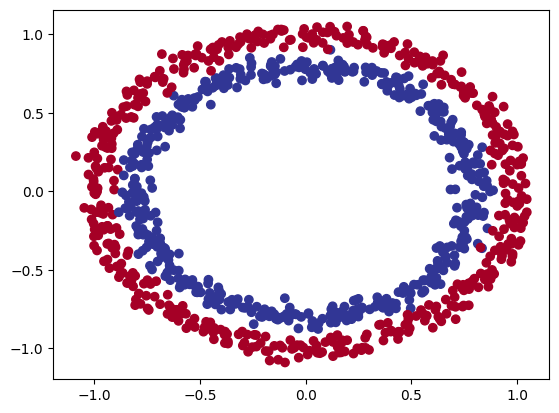

In [10]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_circles(n_samples=n_samples,noise=0.04,random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

#### 2.  Convert to Tensors and Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3. Define the Model Class

In [12]:
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() 
        #Rectified Linear Unit -> A non-linear activation function used in neural networks.
        #Formula: ReLU(x) = max(0, x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
        

#### 4. Instantiate the Model and Inspect Parameters

In [13]:
torch.manual_seed(42)
model = NeuralNetwork()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

#### 5. Define Loss Function and Optimizer

In [14]:
loss_fn = nn.BCEWithLogitsLoss() 

# Binary Cross Entropy does two things internally:
# 1. Converts the model's raw output (logit) into a probability using sigmoid.
# 2. Calculates the Binary Cross-Entropy loss by comparing that probability with the actual label (0 or 1).

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05) #Stochastic Gradient Descent -> uses that error/gradient to improve the model's weights and biases.

#### 6.  Define an Accuracy Function

In [15]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    #Torch.eq check pred and actual value are same or not and sum calulate true values and item convert it into numeric values
    acc = (correct/len(y_true))*100
    return acc

#### 7. Training Loop

In [16]:
# epochs = 1800
epochs = 30000
train_loss_list = []
test_loss_list = []
torch.manual_seed(42)

for epoch in range(epochs):
    # Training
    model.train()

    #compute the predictions #forward pass
    y_logits = model(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) 
    #y_logits are raw outputs, not probabilities. sigmoid convert it betwwen 0 and 1 and roundoff them into class 0 and 1

    #compute the train loss
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy_fn(y_true=y_train, y_pred=y_preds) 

    #zero grad the optimmizer #PyTorch accumulates gradients by default. So before calculating new gradients, we clear the previous ones.
    optimizer.zero_grad() 

    #Backpropagate 
    train_loss.backward() 

    #update the weights
    optimizer.step()

    #Testing
    model.eval()
    with torch.inference_mode(): #disable graident calculation
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    train_loss_list.append(train_loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}| Train Loss {train_loss:.5f}| Train Acc {train_acc:.2f}| Test Loss {test_loss:.5f}| Test Acc {test_acc:.2f}')


Epoch 100| Train Loss 0.69182| Train Acc 59.00| Test Loss 0.69187| Test Acc 60.50
Epoch 200| Train Loss 0.69116| Train Acc 52.62| Test Loss 0.69115| Test Acc 53.00
Epoch 300| Train Loss 0.69050| Train Acc 52.75| Test Loss 0.69042| Test Acc 54.00
Epoch 400| Train Loss 0.68977| Train Acc 53.37| Test Loss 0.68959| Test Acc 53.50
Epoch 500| Train Loss 0.68892| Train Acc 53.62| Test Loss 0.68862| Test Acc 55.00
Epoch 600| Train Loss 0.68793| Train Acc 53.12| Test Loss 0.68751| Test Acc 55.00
Epoch 700| Train Loss 0.68676| Train Acc 53.12| Test Loss 0.68619| Test Acc 55.50
Epoch 800| Train Loss 0.68523| Train Acc 52.88| Test Loss 0.68455| Test Acc 55.50
Epoch 900| Train Loss 0.68328| Train Acc 53.00| Test Loss 0.68255| Test Acc 55.50
Epoch 1000| Train Loss 0.68103| Train Acc 53.12| Test Loss 0.68010| Test Acc 56.50
Epoch 1100| Train Loss 0.67838| Train Acc 53.25| Test Loss 0.67726| Test Acc 55.50
Epoch 1200| Train Loss 0.67520| Train Acc 54.25| Test Loss 0.67389| Test Acc 56.50
Epoch 1300| T

#### 8.  Plot Loss Curves

Text(0.5, 1.0, 'Epochs vs Loss')

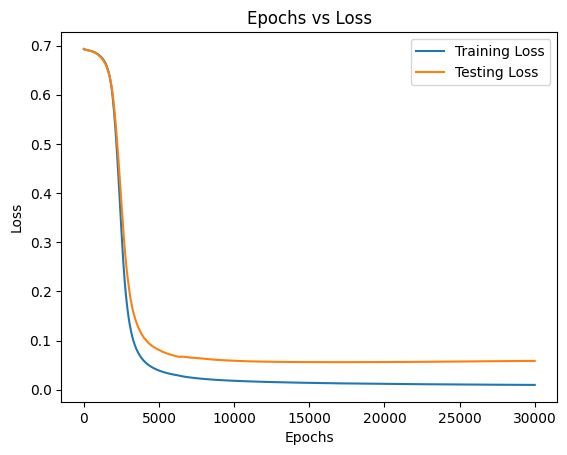

In [17]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss")

#### 9.  Visualize the Decision Boundary

In [18]:
import importlib
import helper_functions
importlib.reload(helper_functions)
from helper_functions import plot_decision_boundary

#### 10. Visualize the Decision Boundary

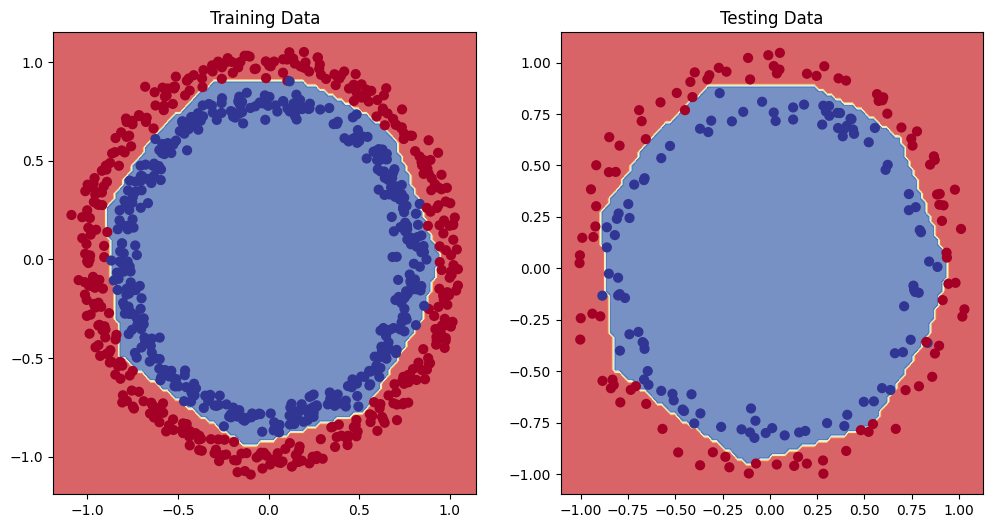

In [19]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)

#### 11. Save trained model

In [20]:
model.eval()

NeuralNetwork(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [21]:
torch.save(model.state_dict(), "model.pth")